In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/csvfiles/05-02-2026/08.35.csv")
AfterPulse = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/AfterPulse.csv")
AfterPulse

,range_m,afterpulse_counts_per_bin,afterpulse_raw
0,0.00,0.0,0.0
1,3.75,0.0,0.0
2,7.50,0.0,0.0
3,11.25,0.0,0.0
4,15.00,0.0,0.0
...,...,...,...
4495,16856.25,NaN,NaN
4496,16860.00,NaN,NaN
4497,16863.75,NaN,NaN
4498,16867.50,NaN,NaN


In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 3000,
    "bg_end_m": 5621.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "k_scale": 0.064021849,
    "b_offset": 0,
    "Energy": 25.51, #mJ
}


In [3]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75
range_m = 2000

# add bin_index (0, 1, 2, ...)
df.insert(0, "bin_index", np.arange(len(df)))

# add range_m (0, 3.75, 7.5, ...)
df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

#find signal to noise ratio
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]

#Change MHz to Photon_per_bin
df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

print(df.head())

   bin_index  range_m    analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00   42.5485      0.216634       149.444000  0.897251   
1          1     3.75   80.8468      0.343724       171.343000  0.886643   
2          2     7.50  185.9210      1.422670        94.270200  1.230210   
3          3    11.25  415.6960      1.583770         0.819741  0.129694   
4          4    15.00  478.9190      0.218849        16.043500  0.587902   

   overflow_info   SNR_analog  SNR_Photon  photon_per_bin  
0            0.0   196.407304  166.557630        3.736100  
1            0.0   235.208481  193.249143        4.283575  
2            0.0   130.684558   76.629356        2.356755  
3            1.0   262.472455    6.320578        0.020494  
4            1.0  2188.353614   27.289412        0.401088  


In [4]:
#Need to cut data from 1500+
#df_0_1500 is data from 0-1500
df_0_1500 = df[(df["range_m"] >= 0) & (df["range_m"] <= 1500)]
#AfterPulse = AfterPulse[(AfterPulse["range_m"] >= 0) & (AfterPulse["range_m"] <= 1500)]

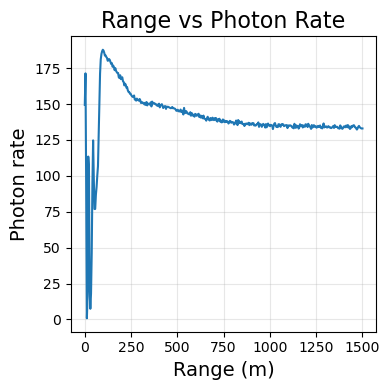

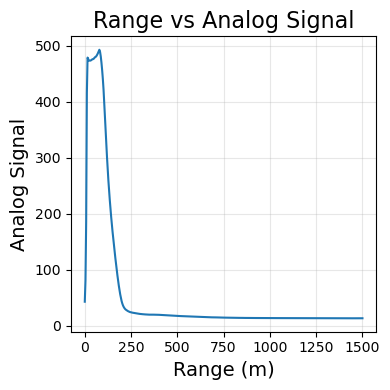

In [5]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

#plot PhotonRate vs Range
plot_xy(
    df_0_1500,
    xcol="range_m",
    ycol="photon_counting",
    yscale="linear",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate",
    outfile="RawFilePicforExample/Prototype/range_vs_photon_rate.png",
)
#plot PhotonRate vs Range
plot_xy(
    df_0_1500,
    xcol="range_m",
    ycol="analog",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_Signal.png",
)

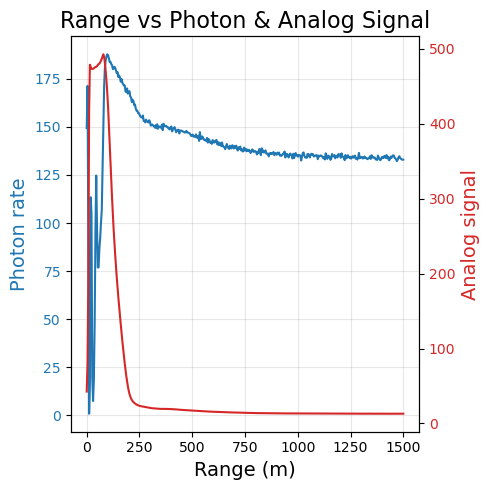

In [6]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_0_1500["range_m"], df_0_1500["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_0_1500["range_m"], df_0_1500["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [7]:
#Find Background for Photon per Bin Rate and Analog Signal
bg_row = df[(df["range_m"] >= config["bg_start_m"]) & (df["range_m"] <= config["bg_end_m"])]

Analog_bg_mean = bg_row["analog"].mean()
Photon_bg_mean = bg_row["photon_per_bin"].mean()

#Show Background value
print("Analog background (mean):", Analog_bg_mean)
print("Photon Per Bin background (mean):", Photon_bg_mean)

Analog background (mean): 12.816124142857145
Photon Per Bin background (mean): 3.3371845


In [8]:
df["analog_bg_corr"] = df["analog"] - Analog_bg_mean
df["Photon_per_bin_bg_corr"] = df["photon_per_bin"] - Photon_bg_mean

In [9]:
df["afterpulse_raw"] = AfterPulse["afterpulse_raw"]
df["afterpulse_counts_per_bin"] = df["afterpulse_raw"] * config["bin_width_ns"] * 1e-3

In [10]:
df["photon_APcorr_counts"] = df["Photon_per_bin_bg_corr"]-df["afterpulse_counts_per_bin"]
bin_width_s = config["bin_width_ns"] * 1e-9
dead_time_s = config["dead_time_ns"] * 1e-9

df["photon_deadtime_counts"] = (
    df["photon_APcorr_counts"]
    / (1 - df["photon_APcorr_counts"] * dead_time_s / bin_width_s)
)

#It will invalid in this case
ratio = df["photon_deadtime_counts"] * dead_time_s / bin_width_s

df["photon_deadtime_corr"] = np.where(
    ratio < 1,
    df["photon_deadtime_counts"] / (1 - ratio),
    np.nan   # invalid / saturated
)

In [11]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_counts,photon_deadtime_corr
0,0,0.00,42.5485,0.216634,149.444000,0.897251,0.0,196.407304,166.557630,3.736100,29.732376,0.398915,0.0,0.0,0.398915,0.419393,0.442087
1,1,3.75,80.8468,0.343724,171.343000,0.886643,0.0,235.208481,193.249143,4.283575,68.030676,0.946390,0.0,0.0,0.946390,1.070382,1.231760
2,2,7.50,185.9210,1.422670,94.270200,1.230210,0.0,130.684558,76.629356,2.356755,173.104876,-0.980430,0.0,0.0,-0.980430,-0.875380,-0.790663
3,3,11.25,415.6960,1.583770,0.819741,0.129694,1.0,262.472455,6.320578,0.020494,402.879876,-3.316691,0.0,0.0,-3.316691,-2.359017,-1.830478
4,4,15.00,478.9190,0.218849,16.043500,0.587902,1.0,2188.353614,27.289412,0.401088,466.102876,-2.936097,0.0,0.0,-2.936097,-2.159882,-1.708268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,12.8293,0.000000,132.380000,0.000000,0.0,inf,inf,3.309500,0.013176,-0.027685,NaN,NaN,NaN,NaN,NaN
3996,3996,14985.00,12.8335,0.000000,134.504000,0.000000,0.0,inf,inf,3.362600,0.017376,0.025415,NaN,NaN,NaN,NaN,NaN
3997,3997,14988.75,12.8328,0.000000,133.367000,0.000000,0.0,inf,inf,3.334175,0.016676,-0.003010,NaN,NaN,NaN,NaN,NaN
3998,3998,14992.50,12.7945,0.000000,133.902000,0.000000,0.0,inf,inf,3.347550,-0.021624,0.010365,NaN,NaN,NaN,NaN,NaN


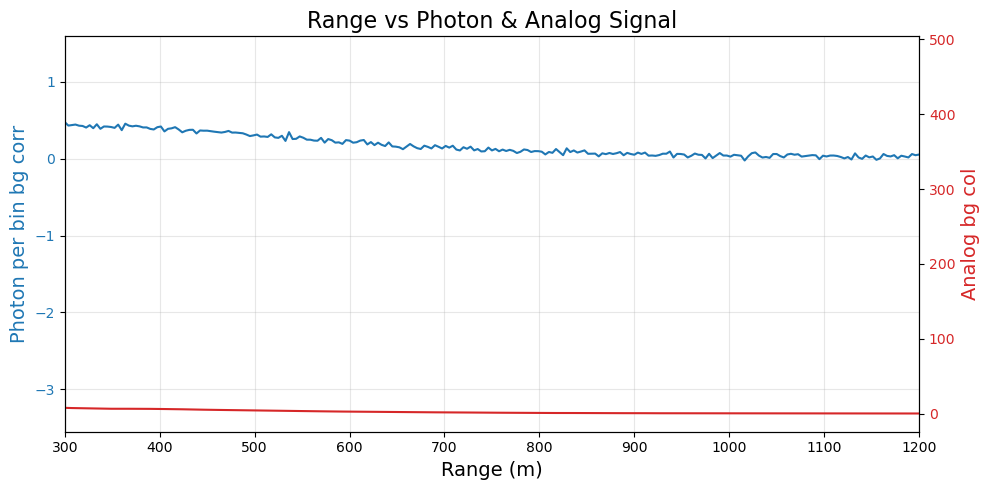

In [12]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["Photon_per_bin_bg_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon per bin bg corr", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog_bg_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog bg col", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ZOOM HERE
ax1.set_xlim(300, 1200)   # try 0–2000 m first

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [13]:
m_overlap = df[(df["range_m"] >= config["overlap_r1_m"]) & (df["range_m"] <= config["overlap_r2_m"])]

x = m_overlap["analog_bg_corr"].to_numpy()
y = m_overlap["Photon_per_bin_bg_corr"].to_numpy()

k_scale, b_offset, r, *_ = linregress(x, y)

print("k_scale =", k_scale,
      "b_offset =", b_offset,
      "R^2 =", r**2)

df["analog_scaled_for_glue"] = k_scale * df["analog_bg_corr"] + b_offset

k_scale = 0.023572132919678565 b_offset = 0.31099373111690803 R^2 = 0.9125035410014154


In [14]:
blend_r1_m = config["overlap_r1_m"] - 100   # or -50
blend_r2_m = config["overlap_r2_m"] + 100   # or +50

r = df["range_m"].to_numpy()

w = np.zeros_like(r, dtype=float)

# r > r2  -> w = 1
w[r > blend_r2_m] = 1.0

# r1 <= r <= r2 -> cosine blend
m = (r >= blend_r1_m) & (r <= blend_r2_m)
w[m] = 0.5 * (1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m)))

df["weight_w"] = w

In [15]:
df["merged_counts_per_bin"] = (
    (1.0 - df["weight_w"]) * df["analog_scaled_for_glue"]
    + df["weight_w"] * df["Photon_per_bin_bg_corr"]
)
df["range2_corrected_counts"] = (
    df["merged_counts_per_bin"] * df["range_m"]**2
)
df["range2_norm"] = (
    df["range2_corrected_counts"] /
    df["range2_corrected_counts"].max()
)


In [16]:
# df["merged_counts_per_bin"] = (
#     (1.0 - df["weight_w"]) * df["analog_scaled_for_glue"]
#     + df["weight_w"] * df["Photon_per_bin_bg_corr"]
# )

# # สำหรับ plotting/comparison ก่อน
# df["merged_counts_clean"] = df["merged_counts_per_bin"].clip(lower=0)

# energy_mJ = config["Energy"]
# energy_J = energy_mJ * 1e-3

# df["range2_corrected_counts"] = (
#     df["merged_counts_clean"] * df["range_m"]**2 / energy_J
# )

# # normalize using trusted near-range only
# ref = df[(df["range_m"] >= 500) & (df["range_m"] <= 3000)]
# scale = ref["range2_corrected_counts"].quantile(0.95)

# df["range2_norm"] = df["range2_corrected_counts"] / scale

# # # smooth more at far range
# # df["range2_smooth"] = df["range2_norm"].copy()

# # mask1 = df["range_m"] >= 3000
# # mask2 = df["range_m"] >= 7000
# # mask3 = df["range_m"] >= 12000

# # df.loc[mask1, "range2_smooth"] = (
# #     df.loc[mask1, "range2_norm"].rolling(window=21, center=True, min_periods=1).mean()
# # )

# # df.loc[mask2, "range2_smooth"] = (
# #     df.loc[mask2, "range2_norm"].rolling(window=51, center=True, min_periods=1).mean()
# # )

# # df.loc[mask3, "range2_smooth"] = (
# #     df.loc[mask3, "range2_norm"].rolling(window=101, center=True, min_periods=1).mean()
# # )

# # # taper far range for display
# # df["range2_display"] = df["range2_smooth"].copy()
# # mask_far = df["range_m"] > 3000
# # df.loc[mask_far, "range2_display"] *= np.exp(-(df.loc[mask_far, "range_m"] - 3000)/5000)

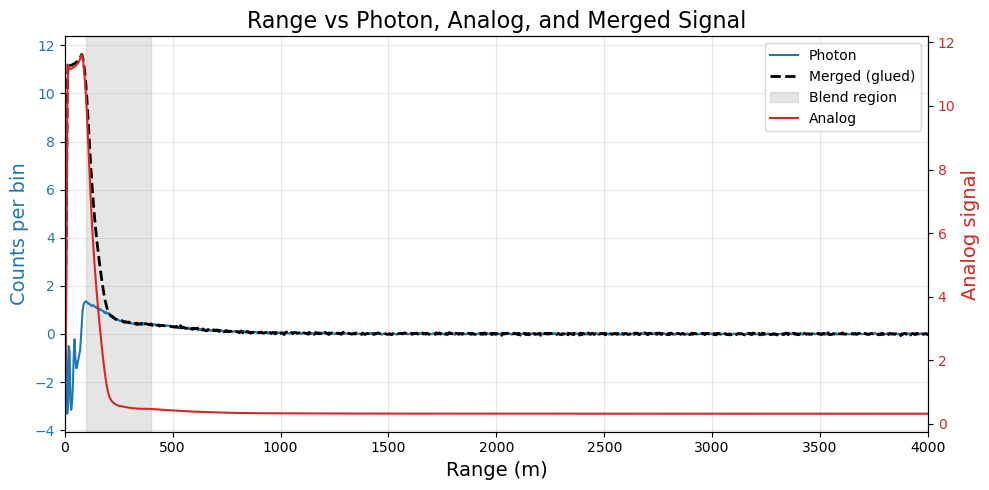

In [17]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- Left y-axis: Photon + Merged ---
ax1.plot(
    df["range_m"],
    df["Photon_per_bin_bg_corr"],
    color="tab:blue",
    label="Photon"
)

ax1.plot(
    df["range_m"],
    df["merged_counts_per_bin"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Merged (glued)"
)

ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# --- Right y-axis: Analog ---
ax2 = ax1.twinx()
ax2.plot(
    df["range_m"],
    df["analog_scaled_for_glue"],
    color="tab:red",
    label="Analog"
)
ax1.axvspan(
    blend_r1_m,
    blend_r2_m,
    color="gray",
    alpha=0.2,
    label="Blend region"
)
ax1.set_xlim(0, 4000) 
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ax1.set_xlim(100, 1500)   # try 0–2000 m first

# --- Legend (combine both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon, Analog, and Merged Signal", fontsize=16)
plt.tight_layout()
plt.show()


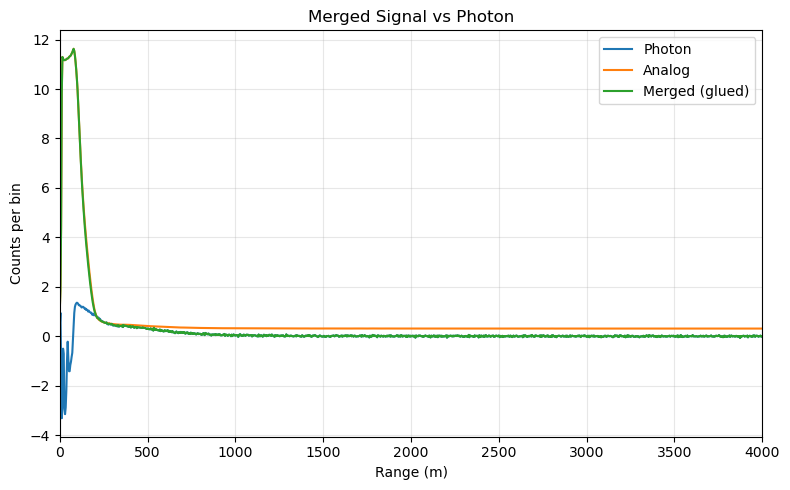

In [18]:
def plot_vs_range(
    df,
    ycols,                  # list ของ column ที่จะ plot
    *,
    xcol="range_m",
    labels=None,            # list ของ label (optional)
    title=None,
    xlabel="Range (m)",
    ylabel=None,
    yscale="linear",        # "linear" or "log"
    xlim=None,
    ylim=None,
    figsize=(8,5),
):
    plt.figure(figsize=figsize)

    if labels is None:
        labels = ycols

    for y, lab in zip(ycols, labels):
        plt.plot(df[xcol], df[y], label=lab)

    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)

    plt.yscale(yscale)

    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_vs_range(
    df,
    ycols=[
        "Photon_per_bin_bg_corr",
        "analog_scaled_for_glue",
        "merged_counts_per_bin",
    ],
    labels=[
        "Photon",
        "Analog",
        "Merged (glued)",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    title="Merged Signal vs Photon",
)



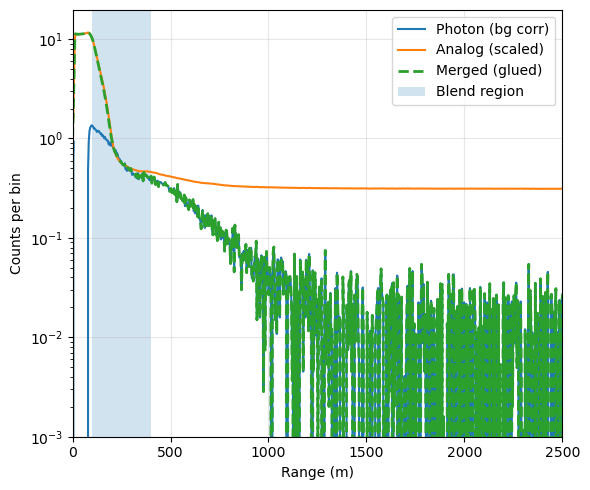

In [19]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df["range_m"], df["Photon_per_bin_bg_corr"], label="Photon (bg corr)")
ax.plot(df["range_m"], df["analog_scaled_for_glue"], label="Analog (scaled)")
ax.plot(df["range_m"], df["merged_counts_per_bin"], "--", linewidth=2, label="Merged (glued)")

ax.axvspan(blend_r1_m, blend_r2_m, alpha=0.2, label="Blend region")
ax.set_xlabel("Range (m)")
ax.set_xlim(0, 2500) 
ax.set_ylabel("Counts per bin")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)   # avoid log(0) issues
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


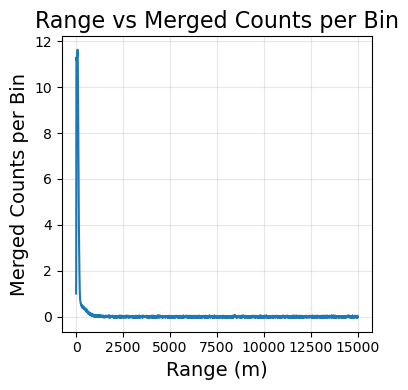

In [20]:
plot_xy(
    df,
    xcol="range_m",
    ycol="merged_counts_per_bin",
    yscale="linear",
    title="Range vs Merged Counts per Bin",
    xlabel="Range (m)",
    ylabel="Merged Counts per Bin",
    outfile="RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

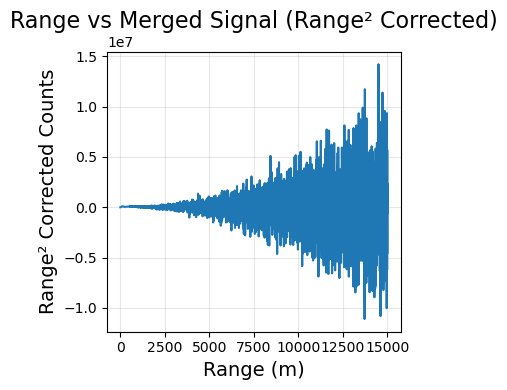

In [21]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_corrected_counts",
    yscale="linear",
    title="Range vs Merged Signal (Range² Corrected)",
    xlabel="Range (m)",
    ylabel="Range² Corrected Counts",
    outfile="RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

In [22]:
# def plot_xy(
#     df,
#     xcol,
#     ycol,
#     *,
#     title=None,
#     xlabel=None,
#     ylabel=None,
#     xscale="linear",
#     yscale="linear",
#     figsize=(4, 4),
#     outfile=None,
#     dpi=300,
# ):
#     # auto labels if not provided
#     if title is None:
#         title = f"{ycol} vs {xcol}"
#     if xlabel is None:
#         xlabel = xcol
#     if ylabel is None:
#         ylabel = ycol

#     plt.figure(figsize=figsize)
#     plt.plot(df[xcol], df[ycol])

#     plt.xlabel(xlabel, fontsize=14)
#     plt.ylabel(ylabel, fontsize=14)
#     plt.title(title, fontsize=16)
#     # plt.ylim(0, 0.04)
#     plt.xscale(xscale)
#     plt.yscale(yscale)

#     plt.grid(True, which="both", alpha=0.3)
#     plt.tight_layout()

#     if outfile is not None:
#         plt.savefig(outfile, dpi=dpi)

#     plt.show()
# plot_xy(
#     df,
#     xcol="range_m",
#     ycol="range2_smooth",
#     yscale="linear",
#     title="Range vs Range² Normalized",
#     xlabel="Range (m)",
#     ylabel="Range² Normalized",
#     outfile="RawFilePicforExample/Prototype/range_vs_Range2_Normalized.png",
# )

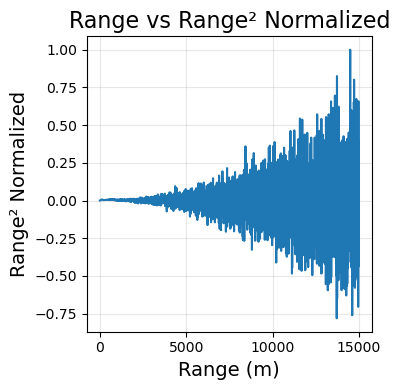

In [23]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Range² Normalized",
    xlabel="Range (m)",
    ylabel="Range² Normalized",
    outfile="RawFilePicforExample/Prototype/range_vs_Range2_Normalized.png",
)

In [24]:
def plot_xy_only_SNR_analog(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
    plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_analog",
    yscale="linear",
    title="Range vs SNR Analog",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_SNR_analog.png",
)

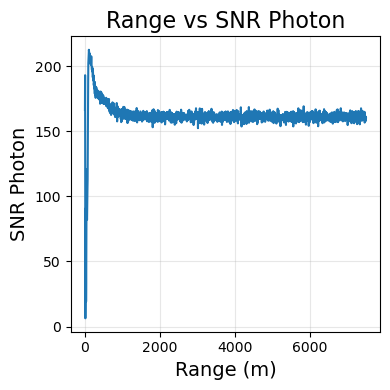

In [25]:
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_Photon",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Photon",
    outfile="RawFilePicforExample/Prototype/range_vs_SNR_Photon.png",
)

In [26]:
m_overlap = (
    (df["range_m"] >= config["overlap_r1_m"]) &
    (df["range_m"] <= config["overlap_r2_m"])
)

ratio = (
    df.loc[m_overlap, "analog_scaled_for_glue"] /
    df.loc[m_overlap, "photon_APcorr_counts"]
)

#On average, the scaled analog signal is (ratio mean - 1) * 100 % higher than the photon signal in the overlap region.
print("ratio mean:", ratio.mean())
#How much the ratio fluctuates from bin to bin around the mean.
print("ratio std :", ratio.std())

ratio mean: 1.0044398757846347
ratio std : 0.05670031915042023


In [27]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,...,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,range2_corrected_counts,range2_norm
0,0,0.00,42.5485,0.216634,149.444000,0.897251,0.0,196.407304,166.557630,3.736100,...,0.0,0.0,0.398915,0.419393,0.442087,1.011849,0.0,1.011849,0.000000e+00,0.000000
1,1,3.75,80.8468,0.343724,171.343000,0.886643,0.0,235.208481,193.249143,4.283575,...,0.0,0.0,0.946390,1.070382,1.231760,1.914622,0.0,1.914622,2.692437e+01,0.000002
2,2,7.50,185.9210,1.422670,94.270200,1.230210,0.0,130.684558,76.629356,2.356755,...,0.0,0.0,-0.980430,-0.875380,-0.790663,4.391445,0.0,4.391445,2.470188e+02,0.000017
3,3,11.25,415.6960,1.583770,0.819741,0.129694,1.0,262.472455,6.320578,0.020494,...,0.0,0.0,-3.316691,-2.359017,-1.830478,9.807732,0.0,9.807732,1.241291e+03,0.000087
4,4,15.00,478.9190,0.218849,16.043500,0.587902,1.0,2188.353614,27.289412,0.401088,...,0.0,0.0,-2.936097,-2.159882,-1.708268,11.298033,0.0,11.298033,2.542057e+03,0.000179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,12.8293,0.000000,132.380000,0.000000,0.0,inf,inf,3.309500,...,NaN,NaN,NaN,NaN,NaN,0.311304,1.0,-0.027685,-6.213450e+06,-0.437123
3996,3996,14985.00,12.8335,0.000000,134.504000,0.000000,0.0,inf,inf,3.362600,...,NaN,NaN,NaN,NaN,NaN,0.311403,1.0,0.025415,5.707056e+06,0.401498
3997,3997,14988.75,12.8328,0.000000,133.367000,0.000000,0.0,inf,inf,3.334175,...,NaN,NaN,NaN,NaN,NaN,0.311387,1.0,-0.003010,-6.761222e+05,-0.047566
3998,3998,14992.50,12.7945,0.000000,133.902000,0.000000,0.0,inf,inf,3.347550,...,NaN,NaN,NaN,NaN,NaN,0.310484,1.0,0.010365,2.329906e+06,0.163912


In [28]:
#MiniMPL
MiniMPL = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/05-02-2026-DATfile/MPL_5038_202602050835.csv")
MiniMPL["range_raw"]

0       0.029979
1       0.059958
2       0.089938
3       0.119917
4       0.149896
         ...    
995    29.859330
996    29.889309
997    29.919287
998    29.949266
999    29.979246
Name: range_raw, Length: 1000, dtype: float64

In [29]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range (m) for NRB": MiniMPL["range_raw"]*1000,
    "range (m)": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize copol nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MiniMPL_for_process_202601050835.csv", index=False)

In [30]:
MiniMPL_for_process = pd.read_csv("MiniMPL_for_process_202601050835.csv")
MiniMPL_for_process

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize copol nrb
0,0.029979,29.979246,119.91698,24.070372,4612.948700,0.271854,2.39834,0.052545
1,0.059958,59.958490,149.89623,11.704313,2224.086200,0.253787,NaN,0.049053
2,0.089938,89.937740,179.87548,10.937408,2075.047600,0.248262,NaN,0.047985
3,0.119917,119.916980,209.85472,10.146125,1922.052200,0.244588,NaN,0.047275
4,0.149896,149.896230,239.83397,9.112822,1722.773000,0.240730,NaN,0.046529
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.195880,0.015028,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.197248,0.278900,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.195954,0.065652,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.194199,-0.315851,NaN,NaN,NaN


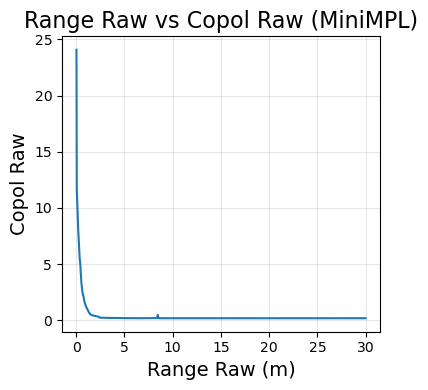

In [31]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_raw",
    yscale="linear",
    title="Range Raw vs Copol Raw (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol Raw",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_Raw(MiniMPL).png",
)

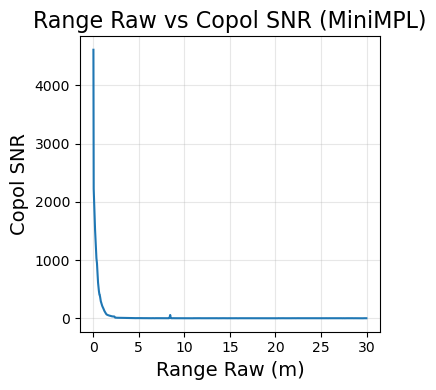

In [32]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_snr",
    yscale="linear",
    title="Range Raw vs Copol SNR (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol SNR",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_SNR(MiniMPL).png",
)

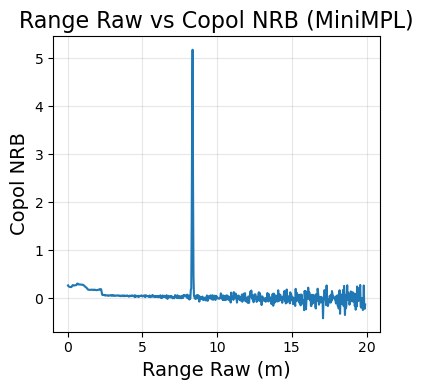

In [33]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_nrb",
    yscale="linear",
    title="Range Raw vs Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol NRB",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_NRB(MiniMPL).png",
)

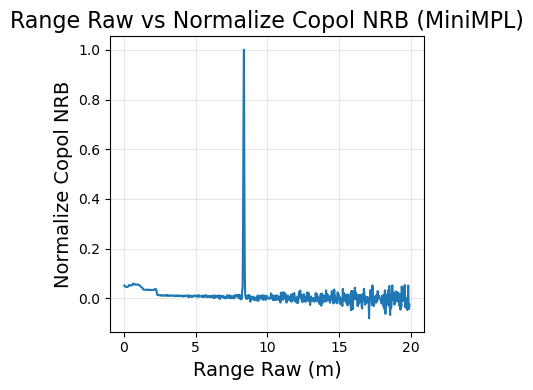

In [34]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="Normalize copol nrb",
    yscale="linear",
    title="Range Raw vs Normalize Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Normalize Copol NRB",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
)

ต้องพยายามทำยังไงก็ได้ ให้ normalized แค่บางช่วง (ให้ความสำคัญแค่บางช่วง) เช่น ช่วง 0-3 km แล้วเอาช่วงอื่นๆ

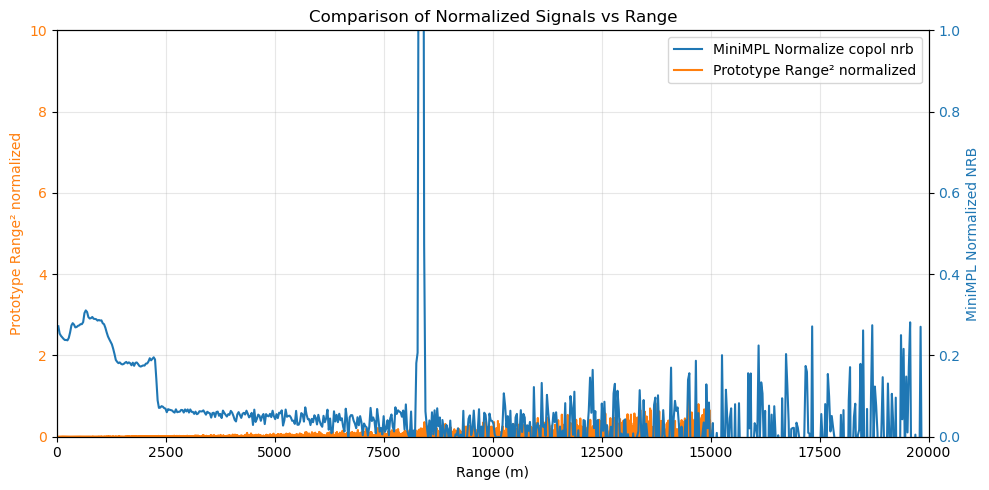

In [36]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    df["range_m"],
    df["range2_norm"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,20000)
ax1.set_ylim(0,10)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

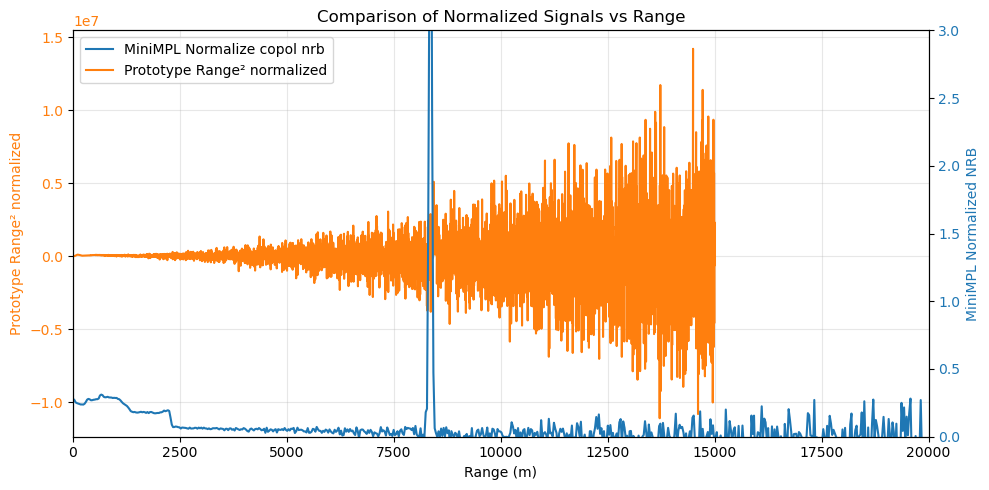

In [37]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    df["range_m"],
    df["range2_corrected_counts"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,20000)
# ax1.set_ylim(0,10)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0,3)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

In [ ]:
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
import matplotlib.pyplot as plt

canvas_widget = None
toolbar = None

def plot_graph():
    global canvas_widget, toolbar

    # ลบกราฟเก่าก่อน ถ้ามี
    if canvas_widget is not None:
        canvas_widget.get_tk_widget().destroy()
        canvas_widget = None

    if toolbar is not None:
        toolbar.destroy()
        toolbar = None

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # ---- Left axis (Prototype) ----
    color1 = "tab:orange"
    ax1.plot(
        df["range_m"],
        df["range2_norm"],
        label="Prototype Range² normalized",
        color=color1,
    )
    ax1.set_xlabel("Range (m)")
    ax1.set_ylabel("Prototype Range² normalized", color=color1)
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.set_xlim(0, 20000)
    ax1.set_ylim(0, 10)

    # ---- Right axis (MiniMPL) ----
    ax2 = ax1.twinx()
    color2 = "tab:blue"
    ax2.plot(
        MiniMPL_for_process["range (m) for NRB"],
        MiniMPL_for_process["copol_nrb"],
        label="MiniMPL Normalize copol nrb",
        color=color2,
    )
    ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)
    ax2.set_ylim(0, 1)

    # ---- Title / grid ----
    ax1.set_title("Comparison of Normalized Signals vs Range")
    ax1.grid(True, alpha=0.3)

    # ---- Combined legend ----
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines2 + lines1, labels2 + labels1, loc="upper right")

    fig.tight_layout()

    # draw inside tkinter
    canvas_widget = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas_widget.draw()
    canvas_widget.get_tk_widget().pack(fill="both", expand=True)

    toolbar = NavigationToolbar2Tk(canvas_widget, toolbar_frame)
    toolbar.update()


# ---- Tkinter window ----
root = tk.Tk()
root.title("LiDAR Signal Viewer")
root.geometry("1000x600")

control_frame = tk.Frame(root)
control_frame.pack(fill="x")

toolbar_frame = tk.Frame(root)
toolbar_frame.pack(fill="x")

plot_frame = tk.Frame(root)
plot_frame.pack(fill="both", expand=True)

btn = tk.Button(control_frame, text="Plot Data", command=plot_graph)
btn.pack(pady=5)

root.mainloop()

In [ ]:
# import tkinter as tk
# from tkinter import messagebox
# from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
# import matplotlib.pyplot as plt

# canvas_widget = None
# toolbar = None

# def get_float(entry, default=None):
#     text = entry.get().strip()
#     if text == "":
#         return default
#     return float(text)

# def plot_graph():
#     global canvas_widget, toolbar

#     try:
#         x_min = get_float(entry_xmin, None)
#         x_max = get_float(entry_xmax, None)

#         y1_min = get_float(entry_y1min, None)
#         y1_max = get_float(entry_y1max, None)

#         y2_min = get_float(entry_y2min, None)
#         y2_max = get_float(entry_y2max, None)

#     except ValueError:
#         messagebox.showerror("Invalid input", "Please enter numeric values only.")
#         return

#     # ลบกราฟเก่า
#     if canvas_widget is not None:
#         canvas_widget.get_tk_widget().destroy()
#         canvas_widget = None

#     if toolbar is not None:
#         toolbar.destroy()
#         toolbar = None

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # ---- Left axis (Prototype) ----
#     color1 = "tab:orange"
#     ax1.plot(
#         df["range_m"],
#         df["range2_norm"],
#         label="Prototype Range² normalized",
#         color=color1,
#     )
#     ax1.set_xlabel("Range (m)")
#     ax1.set_ylabel("Prototype Range² normalized", color=color1)
#     ax1.tick_params(axis="y", labelcolor=color1)

#     # set x / y1 from entries
#     if x_min is not None and x_max is not None:
#         ax1.set_xlim(x_min, x_max)
#     elif x_min is not None:
#         ax1.set_xlim(left=x_min)
#     elif x_max is not None:
#         ax1.set_xlim(right=x_max)

#     if y1_min is not None and y1_max is not None:
#         ax1.set_ylim(y1_min, y1_max)
#     elif y1_min is not None:
#         ax1.set_ylim(bottom=y1_min)
#     elif y1_max is not None:
#         ax1.set_ylim(top=y1_max)

#     # ---- Right axis (MiniMPL) ----
#     ax2 = ax1.twinx()
#     color2 = "tab:blue"
#     ax2.plot(
#         MiniMPL_for_process["range (m) for NRB"],
#         MiniMPL_for_process["copol_nrb"],
#         label="MiniMPL Normalize copol nrb",
#         color=color2,
#     )
#     ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
#     ax2.tick_params(axis="y", labelcolor=color2)

#     if y2_min is not None and y2_max is not None:
#         ax2.set_ylim(y2_min, y2_max)
#     elif y2_min is not None:
#         ax2.set_ylim(bottom=y2_min)
#     elif y2_max is not None:
#         ax2.set_ylim(top=y2_max)

#     # ---- Title / grid ----
#     ax1.set_title("Comparison of Normalized Signals vs Range")
#     ax1.grid(True, alpha=0.3)

#     # ---- Combined legend ----
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines2 + lines1, labels2 + labels1, loc="upper right")

#     fig.tight_layout()

#     # draw inside tkinter
#     canvas_widget = FigureCanvasTkAgg(fig, master=plot_frame)
#     canvas_widget.draw()
#     canvas_widget.get_tk_widget().pack(fill="both", expand=True)

#     toolbar = NavigationToolbar2Tk(canvas_widget, toolbar_frame)
#     toolbar.update()

# def reset_axes():
#     entry_xmin.delete(0, tk.END)
#     entry_xmin.insert(0, "0")

#     entry_xmax.delete(0, tk.END)
#     entry_xmax.insert(0, "20000")

#     entry_y1min.delete(0, tk.END)
#     entry_y1min.insert(0, "0")

#     entry_y1max.delete(0, tk.END)
#     entry_y1max.insert(0, "10")

#     entry_y2min.delete(0, tk.END)
#     entry_y2min.insert(0, "0")

#     entry_y2max.delete(0, tk.END)
#     entry_y2max.insert(0, "1")

# # ---- Tkinter window ----
# root = tk.Tk()
# root.title("LiDAR Signal Viewer")
# root.geometry("1200x700")

# control_frame = tk.Frame(root)
# control_frame.pack(fill="x", padx=10, pady=8)

# toolbar_frame = tk.Frame(root)
# toolbar_frame.pack(fill="x")

# plot_frame = tk.Frame(root)
# plot_frame.pack(fill="both", expand=True)

# # ---- Row 1: x axis ----
# tk.Label(control_frame, text="X min").grid(row=0, column=0, padx=5, pady=5)
# entry_xmin = tk.Entry(control_frame, width=10)
# entry_xmin.grid(row=0, column=1, padx=5, pady=5)

# tk.Label(control_frame, text="X max").grid(row=0, column=2, padx=5, pady=5)
# entry_xmax = tk.Entry(control_frame, width=10)
# entry_xmax.grid(row=0, column=3, padx=5, pady=5)

# # ---- Row 1: y1 axis ----
# tk.Label(control_frame, text="Y1 min").grid(row=0, column=4, padx=5, pady=5)
# entry_y1min = tk.Entry(control_frame, width=10)
# entry_y1min.grid(row=0, column=5, padx=5, pady=5)

# tk.Label(control_frame, text="Y1 max").grid(row=0, column=6, padx=5, pady=5)
# entry_y1max = tk.Entry(control_frame, width=10)
# entry_y1max.grid(row=0, column=7, padx=5, pady=5)

# # ---- Row 1: y2 axis ----
# tk.Label(control_frame, text="Y2 min").grid(row=0, column=8, padx=5, pady=5)
# entry_y2min = tk.Entry(control_frame, width=10)
# entry_y2min.grid(row=0, column=9, padx=5, pady=5)

# tk.Label(control_frame, text="Y2 max").grid(row=0, column=10, padx=5, pady=5)
# entry_y2max = tk.Entry(control_frame, width=10)
# entry_y2max.grid(row=0, column=11, padx=5, pady=5)

# # default values
# reset_axes()

# # buttons
# btn_plot = tk.Button(control_frame, text="Plot Data", command=plot_graph)
# btn_plot.grid(row=0, column=12, padx=10, pady=5)

# btn_reset = tk.Button(control_frame, text="Reset Axes", command=reset_axes)
# btn_reset.grid(row=0, column=13, padx=5, pady=5)

# root.mainloop()